## 🚕 Análisis de Datos de Viajes en Taxi (Enero 2024)
### Este análisis se centra en el conjunto de datos de taxis amarillos de Nueva York para enero de 2024. El objetivo es explorar la distribución de la duración de los viajes, identificar patrones de demanda por tiempo y localizar los corredores de rutas más populares.

## Objetivo
#### Demostrar cómo JupyterLab en AWS (SageMaker Studio) maneja un gran dataset usando R, destacando la escalabilidad y la integración con S3



## Carga de los datos


In [ ]:
data <- read.csv("https://luisvahos14112025.s3.us-east-1.amazonaws.com/yellow_tripdata_2024-01.csv")
head(data)

In [ ]:
library(aws.s3)
library(readr)

bucket <- "s3://luisvahos14112025"
key <- "yellow_tripdata_2024-01.csv"

# Leer desde S3
obj <- get_object(object = key, bucket = bucket)

df <- read_csv(rawToChar(obj))

head(df)


## Duración del Viaje: Calcular la duración exacta de cada viaje (tpep_dropoff_datetime - tpep_pickup_datetime).

In [8]:
# 1. Instalar y cargar la librería dplyr (si no la tienes)
##install.packages("dplyr")
library(dplyr)

# 2. Cargar el archivo CSV
# Asegúrate de que el nombre del archivo es correcto y está en tu directorio de trabajo
data <- read.csv("yellow_tripdata_2024-01.csv")

# 3. Convertir las columnas a formato de fecha y hora (datetime)
# NOTA IMPORTANTE: El formato ("%Y-%m-%d %H:%M:%S") es un ejemplo común.
# Si tus datos tienen un formato diferente (por ejemplo, MM/DD/YYYY),
# deberás ajustar la cadena de 'format'
data$tpep_pickup_datetime <- as.POSIXct(data$tpep_pickup_datetime, format = "%Y-%m-%d %H:%M:%S")
data$tpep_dropoff_datetime <- as.POSIXct(data$tpep_dropoff_datetime, format = "%Y-%m-%d %H:%M:%S")

# 4. Calcular la duración del viaje
# El resultado se almacena en una nueva columna llamada 'trip_duration'.
# El resultado es un objeto 'difftime' y, por defecto, R lo muestra en segundos.
# Puedes especificar unidades (ej. units="mins" o units="hours") si lo deseas.
data <- data %>%
  mutate(
    trip_duration = tpep_dropoff_datetime - tpep_pickup_datetime,
    # Opcional: Para obtener la duración directamente en minutos:
    trip_duration_mins = as.numeric(trip_duration, units = "mins")
  )

# 5. Mostrar las primeras filas con la nueva columna
print(head(data[c("tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration", "trip_duration_mins")]))

  tpep_pickup_datetime tpep_dropoff_datetime trip_duration trip_duration_mins
1  2024-01-01 00:57:55   2024-01-01 01:17:43     1188 secs           19.80000
2  2024-01-01 00:03:00   2024-01-01 00:09:36      396 secs            6.60000
3  2024-01-01 00:17:06   2024-01-01 00:35:01     1075 secs           17.91667
4  2024-01-01 00:36:38   2024-01-01 00:44:56      498 secs            8.30000
5  2024-01-01 00:46:51   2024-01-01 00:52:57      366 secs            6.10000
6  2024-01-01 00:54:08   2024-01-01 01:26:31     1943 secs           32.38333


## El histograma resultante te permitirá ver

La duración más común (el pico más alto de la distribución).
Si la mayoría de los viajes son cortos y solo unos pocos son muy largos (una distribución asimétrica).
Si hay valores atípicos (barras pequeñas muy alejadas a la derecha).

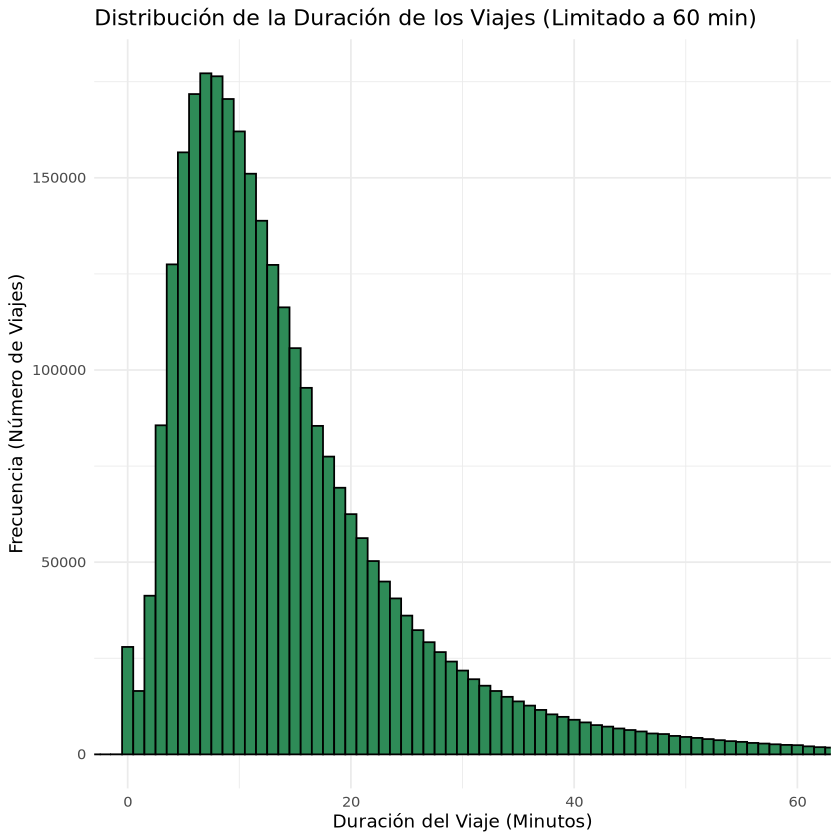

In [10]:
# 1. Carga la librería (si no está cargada)
# install.packages("ggplot2")
library(ggplot2)

# 2. Crea el histograma, limitando el eje X a 60 minutos
histograma_filtrado <- ggplot(data, aes(x = trip_duration_mins)) +
  
  # Utiliza geom_histogram con un buen binwidth
  geom_histogram(binwidth = 1, fill = "seagreen", color = "black") +
  
  # Esta línea es clave: Limita el eje X hasta 60 minutos. 
  # Esto ignora los viajes más largos en el gráfico, pero centra la visualización.
  coord_cartesian(xlim = c(0, 60)) +
  
  # Etiquetas y título
  labs(
    title = "Distribución de la Duración de los Viajes (Limitado a 60 min)",
    x = "Duración del Viaje (Minutos)",
    y = "Frecuencia (Número de Viajes)"
  ) +
  theme_minimal()

# 3. Muestra el nuevo histograma
print(histograma_filtrado)

## El gráfico revela una distribución de la duración con un pico muy pronunciado en los viajes cortos: 

Mayor Frecuencia (El Pico): La barra más alta corresponde al rango de 5 a 10 minutos. Esto significa que la mayoría de los viajes en taxi tienen una duración de entre 5 y 10 minutos (aproximadamente 2.3 millones de viajes). 

Viajes Muy Cortos: El segundo grupo más grande es el de 0 a 5 minutos, con aproximadamente 1.5 millones de viajes. 

La Mayoría de los Viajes: Casi la totalidad de los viajes se concentra en la primera media hora. Los viajes de menos de 15 minutos son, con diferencia, los más comunes, representando la mayoría del dataset. 

Colas Largas: A medida que la duración del viaje aumenta (más de 15 minutos), el número de viajes cae drásticamente, lo cual es típico. Sin embargo, el último bin (el de más de 60 minutos o "> 60") aún tiene un conteo notable (alrededor de 200,000 viajes), lo que indica que una pequeña pero significativa cantidad de viajes duran más de una hora. 

Conclusión 

Este resultado confirma que el servicio de taxi es predominantemente utilizado para viajes de corta y media distancia/duración dentro de la ciudad, siendo el rango óptimo de duración entre 5 y 10 minutos. 

## Tamaño de los datos

In [5]:
dim(data)

[1] 2964624      21

## Patrones de Viaje: Analizar la frecuencia de viajes por hora del día, día de la semana o mes para identificar las horas pico (rush hours) y los días de mayor demanda

In [13]:
# Instala y carga lubridate para manejar fechas y horas
# Si no lo tienes: install.packages("lubridate")
# Si no lo tienes: install.packages("ggplot2")
library(lubridate)
library(dplyr)
library(ggplot2)

## Extracción de Componentes de Tiempo y Agrupación
Crea nuevas columnas para Hora, Día y Mes, y luego cuenta la cantidad de viajes para cada categoría.

In [14]:
# -----------------------------------------------------------
# 1. Extracción de Componentes de Tiempo
# -----------------------------------------------------------

data_analisis <- data %>%
  # Crea las nuevas columnas para el análisis
  mutate(
    # Extrae la hora del día (0-23)
    hora_del_dia = hour(tpep_pickup_datetime),
    
    # Extrae el día de la semana (1=Domingo, 7=Sábado)
    # Se añade label=TRUE para obtener el nombre del día
    dia_de_semana = wday(tpep_pickup_datetime, label = TRUE, abbr = FALSE),
    
    # Extrae el mes (si solo tienes un mes, esto solo te servirá para comparar con otros meses en el futuro)
    mes = month(tpep_pickup_datetime, label = TRUE, abbr = FALSE)
  )

# -----------------------------------------------------------
# 2. Análisis: Conteo de Viajes
# -----------------------------------------------------------

# a) Conteo por Hora del Día (Para identificar horas pico)
viajes_por_hora <- data_analisis %>%
  group_by(hora_del_dia) %>%
  summarise(total_viajes = n())

# b) Conteo por Día de la Semana (Para identificar días de mayor demanda)
viajes_por_dia <- data_analisis %>%
  group_by(dia_de_semana) %>%
  summarise(total_viajes = n())

# c) Conteo por Mes (Si tienes datos de varios meses)
viajes_por_mes <- data_analisis %>%
  group_by(mes) %>%
  summarise(total_viajes = n())

## Visualización de los Patrones (Gráficos)
Ahora, genera las gráficas de barras para visualizar los patrones de demanda:

Gráfico 1: Demanda por Hora del Día (Horas Pico)

[1] "Gráfico 1: Demanda por Hora del Día"


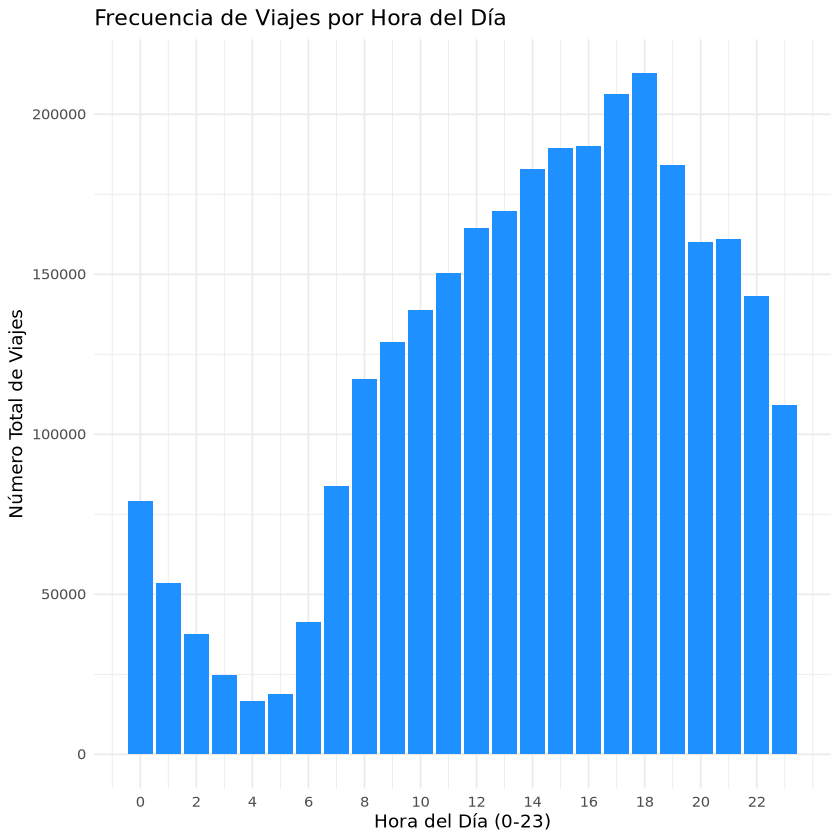

In [15]:
print("Gráfico 1: Demanda por Hora del Día")
ggplot(viajes_por_hora, aes(x = hora_del_dia, y = total_viajes)) +
  geom_bar(stat = "identity", fill = "dodgerblue") +
  labs(
    title = "Frecuencia de Viajes por Hora del Día",
    x = "Hora del Día (0-23)",
    y = "Número Total de Viajes"
  ) +
  scale_x_continuous(breaks = seq(0, 23, 2)) + # Mostrar solo cada 2 horas en el eje X
  theme_minimal()

## Gráfico 1 (Hora del Día): Busca los picos más altos. Es probable que veas picos durante las horas de la mañana (7-9 AM) y de la tarde (4-7 PM), que son las típicas horas pico (rush hours) laborales.

## Gráfico 2: Demanda por Día de la Semana (Días de Mayor Demanda)

[1] "Gráfico 2: Demanda por Día de la Semana"


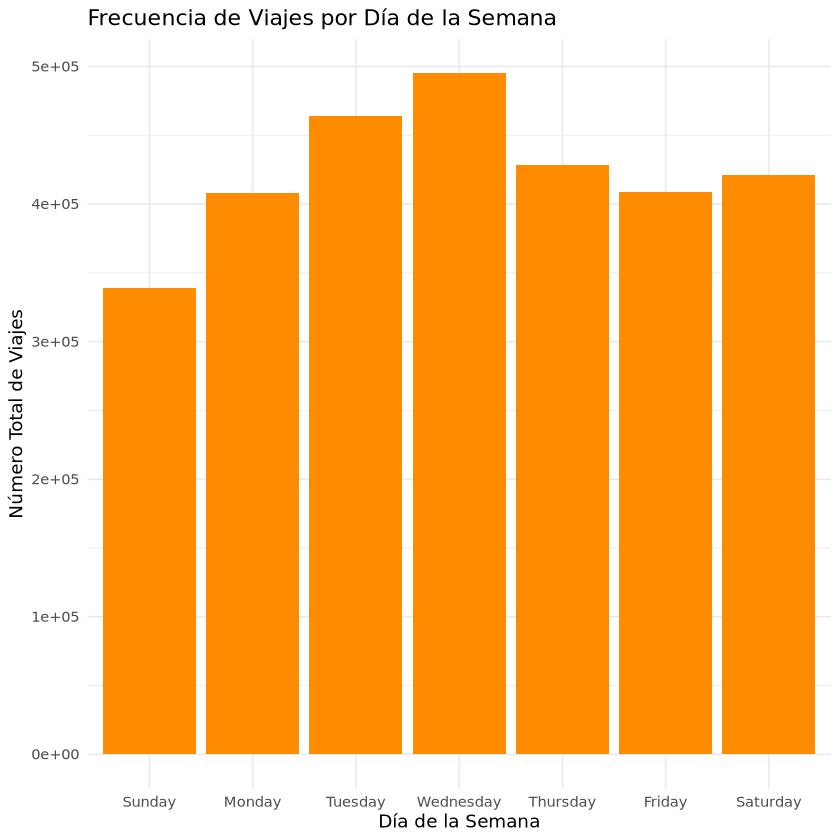

In [16]:
print("Gráfico 2: Demanda por Día de la Semana")
ggplot(viajes_por_dia, aes(x = dia_de_semana, y = total_viajes)) +
  geom_bar(stat = "identity", fill = "darkorange") +
  labs(
    title = "Frecuencia de Viajes por Día de la Semana",
    x = "Día de la Semana",
    y = "Número Total de Viajes"
  ) +
  theme_minimal()

## Gráfico 2 (Día de la Semana): Esto te mostrará los días de mayor demanda. A menudo, los viernes y sábados por la noche tienen una mayor demanda que los domingos o las mañanas de los lunes

## Mapas de Calor de Demanda: Usar PULocationID y DOLocationID para mapear las zonas de la ciudad con más recogidas y destinos (esencialmente, dónde y cuándo la gente quiere ir). 

In [17]:
# -----------------------------------------------------------
# 1. CONTEO DE VIAJES POR ZONA
# -----------------------------------------------------------

# a) Recogidas (PULocationID)
recogidas_top <- data %>%
  group_by(PULocationID) %>%
  summarise(total_viajes = n()) %>%
  arrange(desc(total_viajes)) %>%
  # Tomamos las 15 zonas de recogida más concurridas
  head(15)

# b) Destinos (DOLocationID)
destinos_top <- data %>%
  group_by(DOLocationID) %>%
  summarise(total_viajes = n()) %>%
  arrange(desc(total_viajes)) %>%
  # Tomamos las 15 zonas de destino más concurridas
  head(15)

print("Las 5 zonas de recogida más populares:")
print(head(recogidas_top, 5))
print("---")
print("Las 5 zonas de destino más populares:")
print(head(destinos_top, 5))

[1] "Las 5 zonas de recogida más populares:"
# A tibble: 5 × 2
  PULocationID total_viajes
         <int>        <int>
1          132       145240
2          161       143471
3          237       142708
4          236       136465
5          162       106717
[1] "---"
[1] "Las 5 zonas de destino más populares:"
# A tibble: 5 × 2
  DOLocationID total_viajes
         <int>        <int>
1          236       142044
2          237       130249
3          161       111942
4          230        90603
5          142        89673


## Paso 2: Visualización de Zonas Top (Recogidas y Destinos)
Utilizamos gráficos de barras para visualizar la concentración de la demanda.

Gráfico 1: Zonas de Recogida más Populares

[1] "Gráfico 1: Top 15 Zonas de Recogida"


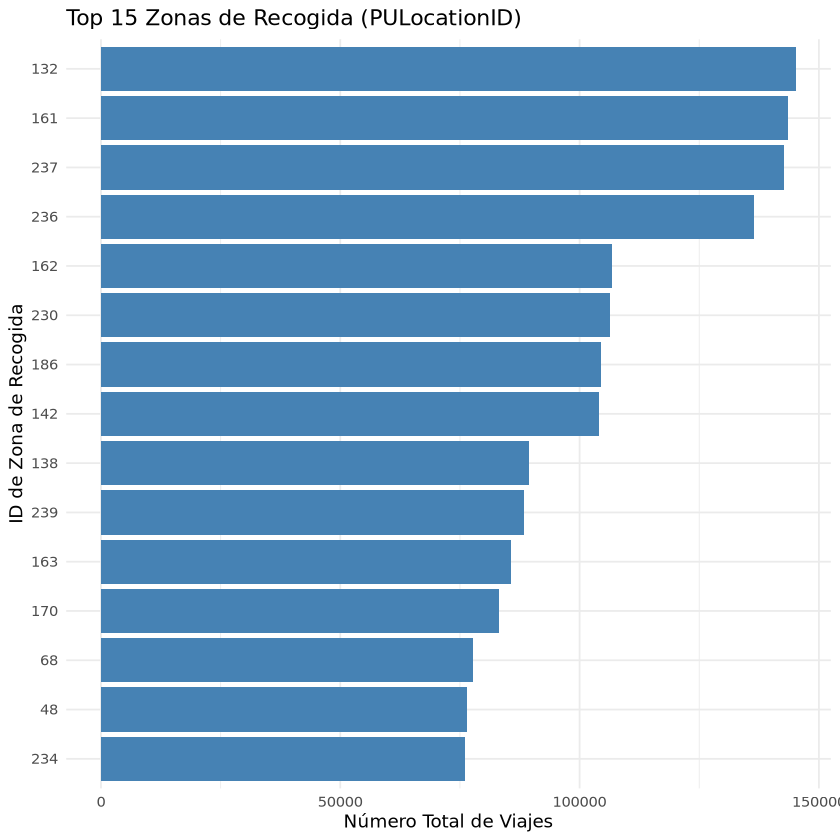

In [18]:
print("Gráfico 1: Top 15 Zonas de Recogida")
ggplot(recogidas_top, aes(x = reorder(PULocationID, total_viajes), y = total_viajes)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(
    title = "Top 15 Zonas de Recogida (PULocationID)",
    x = "ID de Zona de Recogida",
    y = "Número Total de Viajes"
  ) +
  # Voltea el gráfico para mejor legibilidad de las etiquetas
  coord_flip() +
  theme_minimal()

## Gráfico 2: Zonas de Destino más Populares

[1] "Gráfico 2: Top 15 Zonas de Destino"


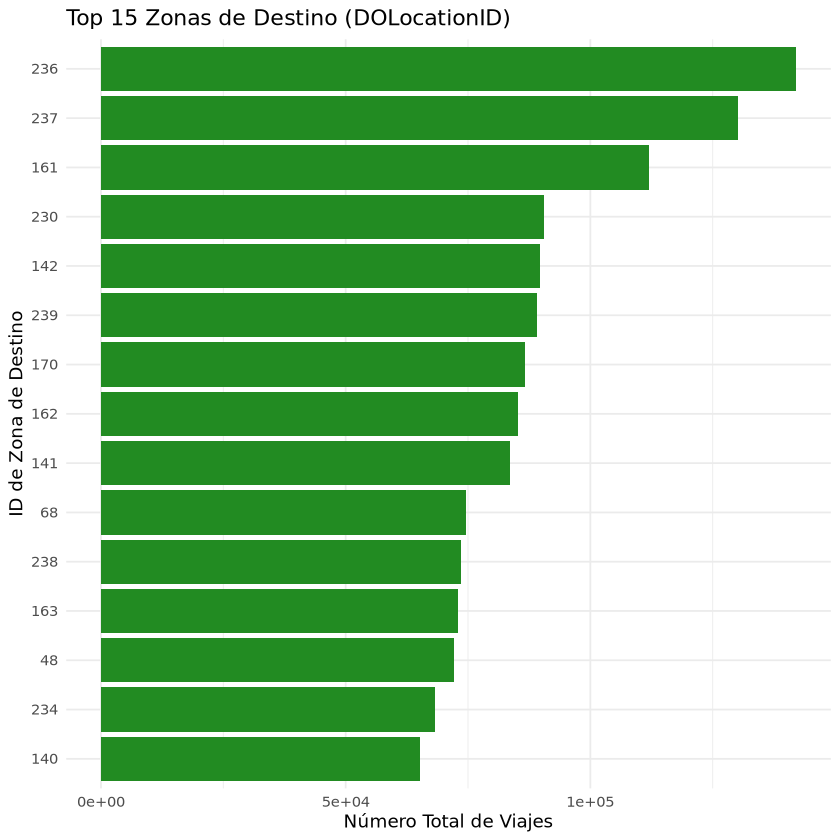

In [19]:
print("Gráfico 2: Top 15 Zonas de Destino")
ggplot(destinos_top, aes(x = reorder(DOLocationID, total_viajes), y = total_viajes)) +
  geom_bar(stat = "identity", fill = "forestgreen") +
  labs(
    title = "Top 15 Zonas de Destino (DOLocationID)",
    x = "ID de Zona de Destino",
    y = "Número Total de Viajes"
  ) +
  coord_flip() +
  theme_minimal()

## Paso 3: Mapa de Calor (Tile Plot) de Pares Origen-Destino
Este es el verdadero Mapa de Calor para ver las rutas más concurridas entre las zonas más populares

`summarise()` has grouped output by 'PULocationID'. You can override using the
`.groups` argument.


[1] "Gráfico 3: Mapa de Calor de Pares Origen-Destino"


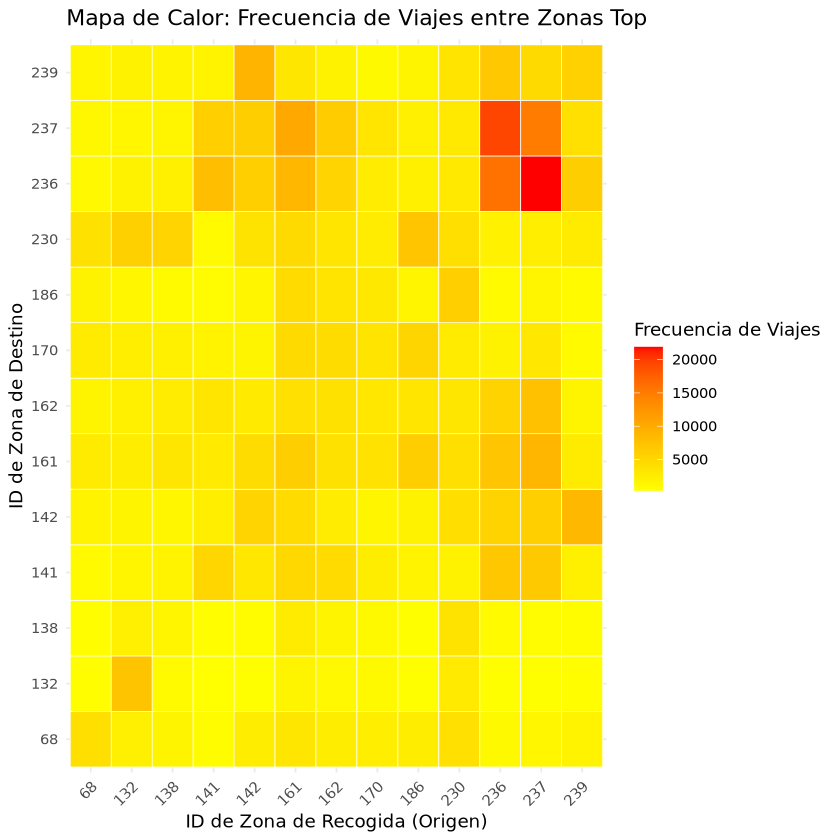

In [20]:
# -----------------------------------------------------------
# 3. MAPA DE CALOR (TILE PLOT) ORÍGEN-DESTINO
# -----------------------------------------------------------

# Identificar las IDs de las 10 zonas MÁS POPULARES (tanto para recogida como destino)
top_10_ids <- unique(c(recogidas_top$PULocationID[1:10], destinos_top$DOLocationID[1:10]))

# Filtrar los datos originales para incluir solo viajes entre las zonas TOP
rutas_top_demanda <- data %>%
  filter(PULocationID %in% top_10_ids & DOLocationID %in% top_10_ids) %>%
  group_by(PULocationID, DOLocationID) %>%
  summarise(conteo_viajes = n())

# Crear el Mapa de Calor (Tile Plot)
print("Gráfico 3: Mapa de Calor de Pares Origen-Destino")
ggplot(rutas_top_demanda, aes(x = factor(PULocationID), y = factor(DOLocationID), fill = conteo_viajes)) +
  # geom_tile crea las celdas del mapa de calor
  geom_tile(color = "white") +
  # Escala de color para el calor (número de viajes)
  scale_fill_gradient(low = "yellow", high = "red", name = "Frecuencia de Viajes") +
  labs(
    title = "Mapa de Calor: Frecuencia de Viajes entre Zonas Top",
    x = "ID de Zona de Recogida (Origen)",
    y = "ID de Zona de Destino"
  ) +
  theme_minimal() +
  # Ajustar texto para que no se superponga
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Interpretación del Mapa de Calor
Cada celda (cuadrado) representa una ruta específica (un PULocationID en el eje X a un DOLocationID en el eje Y).

El color indica la intensidad de la demanda: las celdas con colores más oscuros o intensos (rojo) son las rutas más transitadas.

Esto te permite identificar rápidamente los corredores de demanda; por ejemplo, si ves una fila o columna muy roja, esa zona es un destino o un origen extremadamente popular.

[1] "Gráfico 3: Mapa de Calor de Pares Origen-Destino"


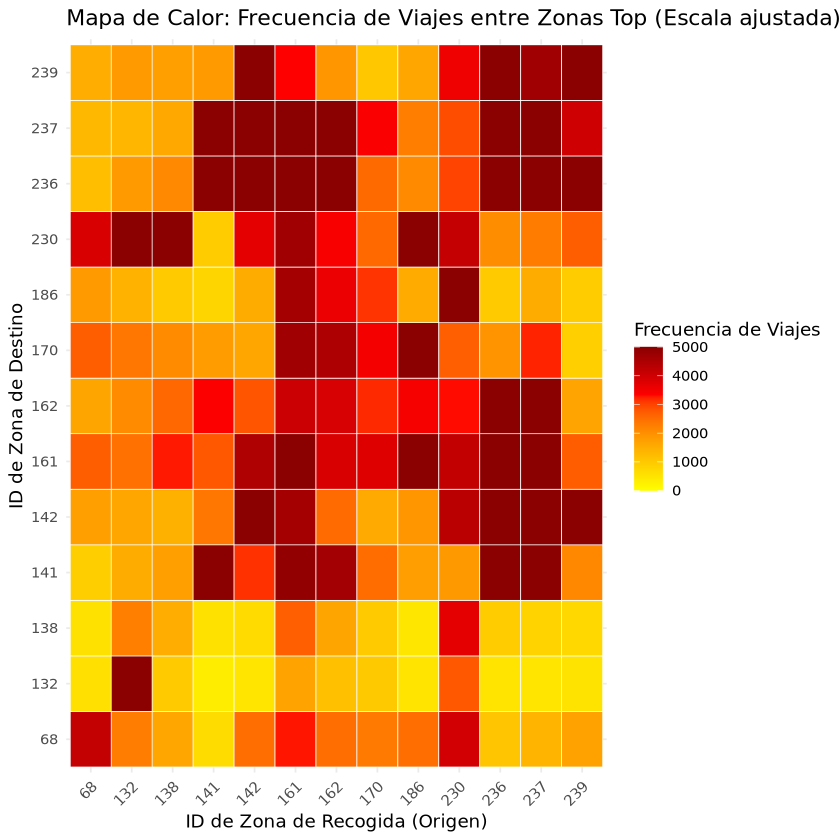

In [23]:
library(ggplot2)

print("Gráfico 3: Mapa de Calor de Pares Origen-Destino")
ggplot(rutas_top_demanda, aes(x = factor(PULocationID), y = factor(DOLocationID), fill = conteo_viajes)) +
  geom_tile(color = "white") +
  
  # Usar scale_fill_gradientn para un mejor control
  scale_fill_gradientn(
    name = "Frecuencia de Viajes",
    colors = c("yellow", "orange", "red", "darkred"),
    # Limita la escala a 5000 (o un valor que elijas)
    # Los valores superiores a este límite se mostrarán con el color más oscuro (darkred)
    limits = c(0, 5000), 
    # Mantiene los valores fuera de los límites en el color superior (darkred)
    oob = scales::squish 
  ) +
  
  labs(
    title = "Mapa de Calor: Frecuencia de Viajes entre Zonas Top (Escala ajustada)",
    x = "ID de Zona de Recogida (Origen)",
    y = "ID de Zona de Destino"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### El cambio clave es en la línea limits = c(0, 5000).

¿Qué hace? Le dice al gráfico que considere 5000 como el valor máximo de la escala de color.

Resultado: Cualquier celda con un conteo de viajes superior a 5000 (como tus celdas de 15,000 o 20,000) ahora se coloreará con el color más intenso (el último de la paleta, darkred), pero el resto de las celdas (las que están entre 0 y 5000) ahora usarán la gama de colores completa (yellow a red), permitiendo ver diferencias que antes eran invisibles.

Prueba con 5000, y si el gráfico sigue estando muy amarillo, baja el límite a 3000 o 2000.

## Rutas Comunes: Identificar las rutas más frecuentes entre pares de zonas

## Paso 1: Conteo y Clasificación de Rutas
Este código agrupa los datos por el par de zonas (Origen y Destino) y cuenta cuántas veces ocurrió cada ruta

In [24]:
library(dplyr)
library(ggplot2)

# -----------------------------------------------------------
# 1. Agrupar y Contar las Rutas
# -----------------------------------------------------------

rutas_comunes <- data %>%
  # Aseguramos que las IDs de ubicación sean tratadas como números o factores para el agrupamiento
  mutate(
    PULocationID = as.character(PULocationID),
    DOLocationID = as.character(DOLocationID)
  ) %>%
  
  # Agrupamos por la combinación única de Origen y Destino
  group_by(PULocationID, DOLocationID) %>%
  
  # Contamos el número de viajes para cada ruta
  summarise(
    conteo_viajes = n(),
    .groups = "drop" # Mantiene el código limpio eliminando la agrupación implícita
  ) %>%
  
  # Ordenamos los resultados de forma descendente (la ruta más frecuente al inicio)
  arrange(desc(conteo_viajes))
  
# -----------------------------------------------------------
# 2. Mostrar las 10 Rutas Más Frecuentes
# -----------------------------------------------------------

print("Tabla de las 10 Rutas (Pares Origen-Destino) Más Comunes:")
print(head(rutas_comunes, 10))

[1] "Tabla de las 10 Rutas (Pares Origen-Destino) Más Comunes:"
# A tibble: 10 × 3
   PULocationID DOLocationID conteo_viajes
   <chr>        <chr>                <int>
 1 237          236                  21883
 2 236          237                  19402
 3 236          236                  15955
 4 237          237                  14938
 5 161          237                  10275
 6 142          239                   8980
 7 237          161                   8834
 8 161          236                   8766
 9 239          142                   8675
10 239          238                   8445


## Paso 2: Visualización de las Rutas Top
Para una mejor comprensión visual de las rutas más comunes, puedes graficar las Top 10 rutas:

[1] "Gráfico de las 10 Rutas Más Frecuentes"


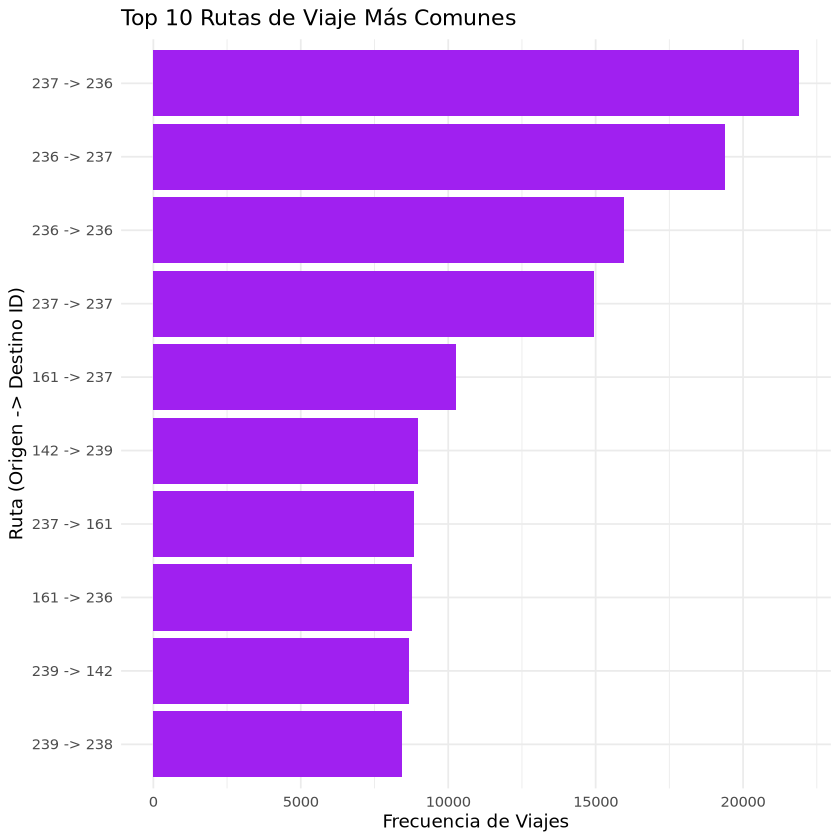

In [25]:
# -----------------------------------------------------------
# 3. Visualización de las 10 Rutas Más Frecuentes
# -----------------------------------------------------------

# Crear una etiqueta legible combinando Origen y Destino
rutas_top_10 <- head(rutas_comunes, 10) %>%
  mutate(ruta = paste0(PULocationID, " -> ", DOLocationID)) # Combina IDs para la etiqueta

print("Gráfico de las 10 Rutas Más Frecuentes")
ggplot(rutas_top_10, aes(x = reorder(ruta, conteo_viajes), y = conteo_viajes)) +
  geom_bar(stat = "identity", fill = "purple") +
  labs(
    title = "Top 10 Rutas de Viaje Más Comunes",
    x = "Ruta (Origen -> Destino ID)",
    y = "Frecuencia de Viajes"
  ) +
  coord_flip() + # Voltea las coordenadas para mejor legibilidad de las rutas largas
  theme_minimal()

## El resultado del print(head(rutas_comunes, 10)) muestra directamente los pares de PULocationID y DOLocationID que tienen el mayor volumen de viajes, revelando los corredores de transporte clave en tus datos. El gráfico de barras te dará una idea clara de la diferencia en la popularidad entre la ruta #1 y el resto de las rutas del top 10